# 03 — eBOSS DR16Q $\times$ DESI DR1 QSO: cross-match and weighting

This notebook demonstrates the complete oneuniverse pipeline on real data:

1. **Open** the two-survey database (eBOSS + DESI quasars).
2. **Inspect** the cross-survey ONEUID index — 234k quasars seen by both.
3. **Define per-survey weights** that reflect the actual DESI/eBOSS systematics.
4. **Combine** the overlapping measurements with three strategies.
5. **Visualise** the footprints, redshift comparison, and weight properties.

---

### Database build (done once)

```bash
# From a config file pointing at the raw FITS catalogs:
python -c "
from oneuniverse.data import OneuniverseDatabase
db = OneuniverseDatabase.from_config('oneuniverse.ini')
db.build_oneuid(sky_tol_arcsec=2.0, dz_tol=5e-3)
"
```

After that, the database root contains:
- `spectroscopic/eboss/qso/oneuniverse/` — 919k confirmed QSOs
- `spectroscopic/desi/dr1/qso/oneuniverse/` — 1.265M QSOs (SPECTYPE=QSO, ZWARN=0)
- `_oneuid_index.parquet` — the cross-match sidecar (1.9M unique, 234k shared)

In [1]:
from pathlib import Path
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from oneuniverse.data import OneuniverseDatabase, Cone, Shell, SkyPatch

DB_ROOT = Path('/home/ravoux/Documents/Science/Cosmography/oneuniverse_database')
db = OneuniverseDatabase(DB_ROOT)
print(db.summary())

/home/ravoux/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


OneuniverseDatabase @ /home/ravoux/Documents/Science/Cosmography/oneuniverse_database
  2 dataset(s):
  - spectroscopic_desi_dr1_qso                [spectroscopic  ] point     n_rows= 1,265,294
  - spectroscopic_eboss_qso                   [spectroscopic  ] point     n_rows=   919,374


## 1. The cross-survey ONEUID index

Each row in the index is a (oneuid, dataset, row_index) triple.  If an object was observed by both eBOSS and DESI, two rows share the same `oneuid`.

In [2]:
idx = db.load_oneuid()
print(idx)
print(f'  sky_tol_arcsec : {idx.sky_tol_arcsec}')
print(f'  dz_tol         : {idx.dz_tol}')
print(f'  total rows     : {len(idx.table):,}')
print(f'  unique objects : {idx.n_unique:,}')
print(f'  multi-survey   : {idx.n_multi:,}')

<OneuidIndex n_rows=2184668 n_unique=1918486 n_multi=234034>
  sky_tol_arcsec : 2.0
  dz_tol         : 0.005
  total rows     : 2,184,668
  unique objects : 1,918,486
  multi-survey   : 234,034


In [3]:
# Per-dataset breakdown
for ds in idx.datasets():
    n = (idx.table['dataset'] == ds).sum()
    print(f'  {ds:45s}  {n:>10,} rows')

  spectroscopic_desi_dr1_qso                      1,265,294 rows
  spectroscopic_eboss_qso                           919,374 rows


In [4]:
# Show a few cross-matched objects
q = db.oneuid_query(index=idx)
multi = idx.multi_only()
sample_uids = multi['oneuid'].unique()[:3]

for uid in sample_uids:
    rows = q.concurrences(int(uid))
    print(f'\nONEUID {uid}:')
    print(rows[['oneuid', 'dataset', 'ra', 'dec', 'z']].to_string(index=False))


ONEUID 38063:
 oneuid                    dataset       ra        dec        z
  38063 spectroscopic_desi_dr1_qso 6.672750 -11.130130 0.663525
  38063    spectroscopic_eboss_qso 6.672727 -11.130114 0.663184

ONEUID 38066:
 oneuid                    dataset       ra        dec        z
  38066 spectroscopic_desi_dr1_qso 6.714347 -11.214563 1.118594
  38066    spectroscopic_eboss_qso 6.714344 -11.214561 1.117861

ONEUID 38109:
 oneuid                    dataset       ra        dec        z
  38109 spectroscopic_desi_dr1_qso 8.124195 -11.163108 1.599019
  38109    spectroscopic_eboss_qso 8.124195 -11.163100 1.599209


## 2. Sky footprints and overlap region

eBOSS observed the northern sky (BOSS footprint, ~10k deg$^2$); DESI covers a broader footprint but the overlap is substantial in the northern galactic cap.

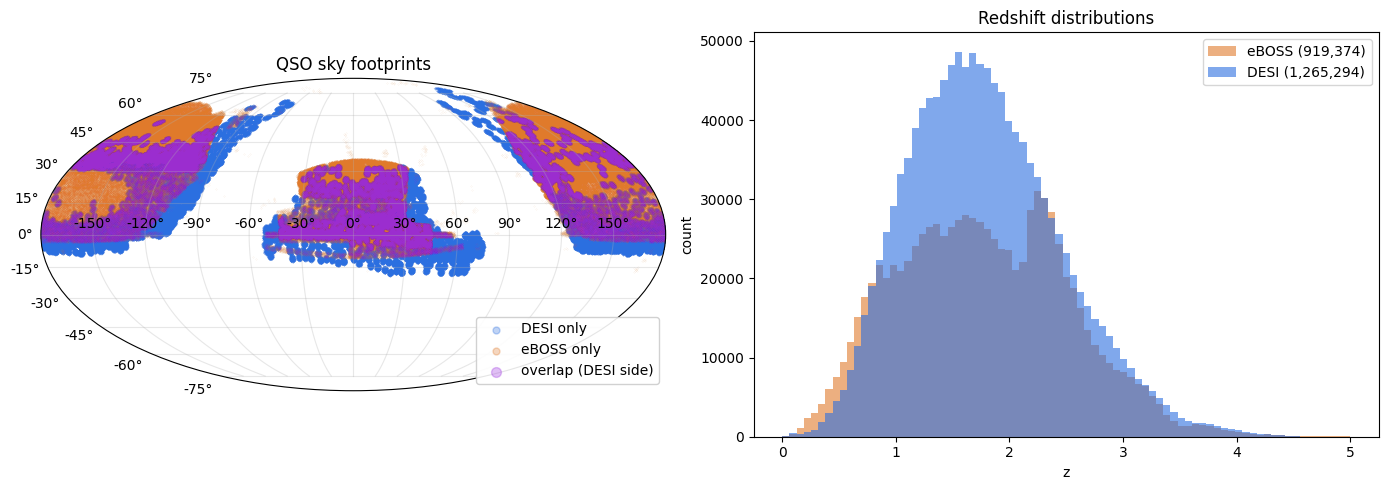

In [5]:
from oneuniverse.data.converter import read_oneuniverse_parquet

t = idx.table
eboss_mask = t['dataset'] == 'spectroscopic_eboss_qso'
desi_mask  = t['dataset'] == 'spectroscopic_desi_dr1_qso'
multi_uids = set(multi['oneuid'].unique())
overlap_mask = t['oneuid'].isin(multi_uids)

fig = plt.figure(figsize=(14, 5))

ax = fig.add_subplot(1, 2, 1, projection='mollweide')
for mask, label, color, s in [
    (desi_mask & ~overlap_mask, 'DESI only',  '#2b6fe0', 0.01),
    (eboss_mask & ~overlap_mask, 'eBOSS only', '#e07a2b', 0.01),
    (overlap_mask & desi_mask, 'overlap (DESI side)', '#9b2de0', 0.02),
]:
    ra = t.loc[mask, 'ra'].to_numpy()
    dec = t.loc[mask, 'dec'].to_numpy()
    ra_rad = np.radians(np.where(ra > 180, ra - 360, ra))
    ax.scatter(ra_rad, np.radians(dec), s=s, alpha=0.3,
               c=color, label=label, rasterized=True)
ax.set_title('QSO sky footprints')
ax.legend(loc='lower right', markerscale=50, framealpha=0.9)
ax.grid(alpha=0.3)

ax = fig.add_subplot(1, 2, 2)
z_eboss = t.loc[eboss_mask, 'z'].to_numpy()
z_desi  = t.loc[desi_mask, 'z'].to_numpy()
bins = np.linspace(0, 5, 80)
ax.hist(z_eboss, bins=bins, alpha=0.6, color='#e07a2b', label=f'eBOSS ({len(z_eboss):,})', edgecolor='none')
ax.hist(z_desi, bins=bins, alpha=0.6, color='#2b6fe0', label=f'DESI ({len(z_desi):,})', edgecolor='none')
ax.set_xlabel('z')
ax.set_ylabel('count')
ax.set_title('Redshift distributions')
ax.legend()

fig.tight_layout()
plt.show()

## 3. Redshift consistency of the cross-match

For the 234k objects seen by both surveys, compare the eBOSS best-$z$ with the DESI Redrock $z$.

In [6]:
eboss_rows = multi[multi['dataset'] == 'spectroscopic_eboss_qso'].drop_duplicates('oneuid').set_index('oneuid')
desi_rows  = multi[multi['dataset'] == 'spectroscopic_desi_dr1_qso'].drop_duplicates('oneuid').set_index('oneuid')
common = eboss_rows.index.intersection(desi_rows.index)

z_e = eboss_rows.loc[common, 'z'].values
z_d = desi_rows.loc[common, 'z'].values
dz = z_d - z_e

print(f'{len(common):,} cross-matched QSOs')
print(f'  median |dz| = {np.median(np.abs(dz)):.6f}')
print(f'  P90    |dz| = {np.percentile(np.abs(dz), 90):.6f}')
print(f'  |dz|<1e-3   : {(np.abs(dz) < 1e-3).sum():,} ({100*(np.abs(dz)<1e-3).mean():.1f}%)')

234,034 cross-matched QSOs
  median |dz| = 0.001255
  P90    |dz| = 0.003730
  |dz|<1e-3   : 98,708 (42.2%)


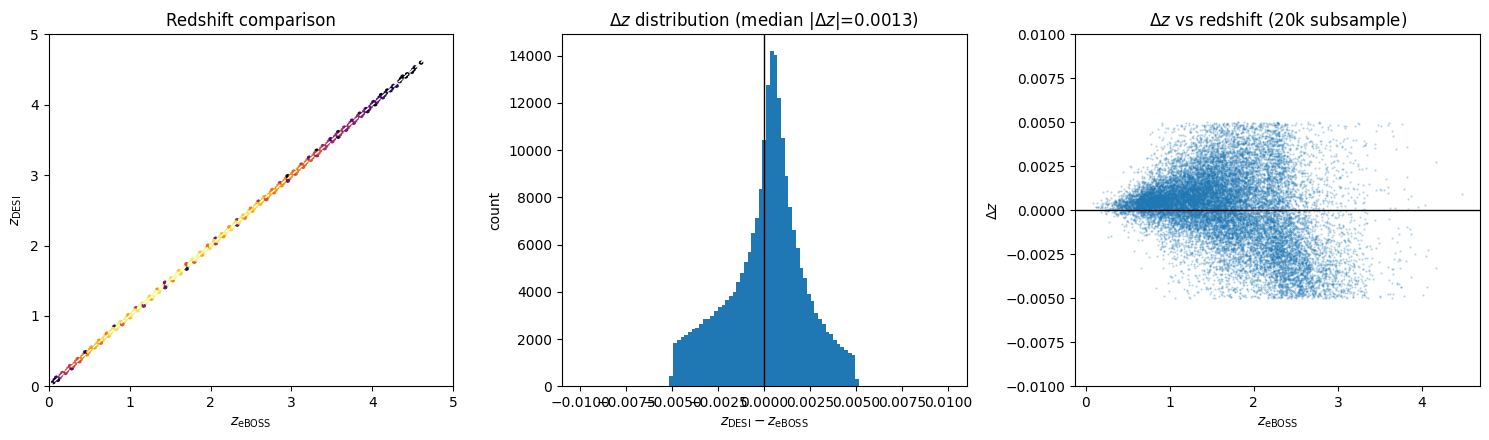

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# z-z scatter (density)
ax = axes[0]
ax.hexbin(z_e, z_d, gridsize=120, cmap='inferno', bins='log', mincnt=1)
ax.plot([0, 5], [0, 5], 'w--', lw=1)
ax.set_xlabel('$z_{\\mathrm{eBOSS}}$')
ax.set_ylabel('$z_{\\mathrm{DESI}}$')
ax.set_title('Redshift comparison')
ax.set_xlim(0, 5); ax.set_ylim(0, 5)

# dz histogram
ax = axes[1]
ax.hist(dz, bins=np.linspace(-0.01, 0.01, 100), color='C0', edgecolor='none')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('$z_{\\mathrm{DESI}} - z_{\\mathrm{eBOSS}}$')
ax.set_ylabel('count')
ax.set_title(f'$\\Delta z$ distribution (median $|\\Delta z|$={np.median(np.abs(dz)):.4f})')

# dz vs z
ax = axes[2]
subsample = np.random.default_rng(42).choice(len(z_e), min(20_000, len(z_e)), replace=False)
ax.scatter(z_e[subsample], dz[subsample], s=0.3, alpha=0.3, c='C0', rasterized=True)
ax.axhline(0, color='k', lw=1)
ax.set_xlabel('$z_{\\mathrm{eBOSS}}$')
ax.set_ylabel('$\\Delta z$')
ax.set_ylim(-0.01, 0.01)
ax.set_title('$\\Delta z$ vs redshift (20k subsample)')

fig.tight_layout()
plt.show()

## 4. Defining per-survey weights

For a real cosmological analysis the total weight per QSO is a product of several terms:

| Weight | eBOSS | DESI | Purpose |
|--------|-------|------|---------|
| **Redshift quality** | `sn_median > 0` | `ZWARN == 0` (pre-applied) | Drop catastrophic failures |
| **Spectral S/N** | `sn_median` | `tsnr2_qso` | How well measured is the spectrum |
| **Redshift failure** | — | `w_zfail` | Correct for fibers with no valid $z$ |
| **Fiber completeness** | — | `comp_tile` | Unobserved targets due to tiling |
| **FKP** (optional) | $w_{\rm FKP}(z)$ | $w_{\rm FKP}(z)$ | Optimal density weighting for P(k) |

Below we define a realistic weight per survey and compose them with the `oneuniverse.combine` API.

In [ ]:
from oneuniverse.combine import (
    InverseVarianceWeight,
    ColumnWeight,
    QualityMaskWeight,
    FKPWeight,
    WeightedCatalog,
    combine_weights,
    default_weight_for,
)

### 4a. Load the cross-matched subset with the columns we need

We use the tiered loading API: `partial_for` loads only the columns we need from the Parquet files.

In [9]:
multi_uids = idx.multi_only()['oneuid'].unique()

# eBOSS columns: sn_median, z_spec_err
t0 = time.perf_counter()
df_eboss = q.partial_for(
    multi_uids,
    columns=['sn_median', 'z_spec_err', 'bal_prob'],
    datasets=['spectroscopic_eboss_qso'],
)
print(f'eBOSS partial_for : {(time.perf_counter()-t0)*1e3:.0f} ms  -> {df_eboss.shape}')

# DESI columns: tsnr2_qso, z_spec_err, w_zfail, comp_tile
t0 = time.perf_counter()
df_desi = q.partial_for(
    multi_uids,
    columns=['tsnr2_qso', 'z_spec_err', 'w_zfail', 'comp_tile', 'prob_obs'],
    datasets=['spectroscopic_desi_dr1_qso'],
)
print(f'DESI  partial_for : {(time.perf_counter()-t0)*1e3:.0f} ms  -> {df_desi.shape}')

df_eboss.head(3)

eBOSS partial_for : 129 ms  -> (266159, 9)
DESI  partial_for : 137 ms  -> (234057, 11)


,oneuid,dataset,row_index,ra,dec,z,sn_median,z_spec_err,bal_prob
0,38063,spectroscopic_eboss_qso,27513,6.672727,-11.130114,0.663184,7.159719,0.0,-1.0
1,38066,spectroscopic_eboss_qso,27686,6.714344,-11.214561,1.117861,7.254401,0.0,-1.0
2,38109,spectroscopic_eboss_qso,33379,8.124195,-11.163100,1.599209,15.656496,0.0,1.0


In [10]:
df_desi.head(3)

,oneuid,dataset,row_index,ra,dec,z,tsnr2_qso,z_spec_err,w_zfail,comp_tile,prob_obs
0,38063,spectroscopic_desi_dr1_qso,38063,6.672750,-11.130130,0.663525,37.639671,0.000017,1.0,0.772702,1.0
1,38066,spectroscopic_desi_dr1_qso,38066,6.714347,-11.214563,1.118594,36.433426,0.000195,1.0,0.772702,1.0
2,38109,spectroscopic_desi_dr1_qso,38109,8.124195,-11.163108,1.599019,32.457321,0.000126,1.0,0.748187,1.0


### 4b. Per-survey weight construction

We now define the individual weight terms.

In [11]:
# ── eBOSS weights ──
# S/N weight: proportional to median spectral S/N
# Quality cut: remove objects with sn_median <= 0 (bad reductions)
sn = df_eboss['sn_median'].to_numpy(dtype=np.float64)
w_sn_eboss = np.where(sn > 0, sn / np.nanmedian(sn[sn > 0]), 0.0)

# BAL mask: down-weight BAL QSOs (bal_prob > 0.5)
bal = df_eboss['bal_prob'].to_numpy(dtype=np.float64)
w_bal = np.where((bal >= 0) & (bal <= 0.5), 1.0, 0.1)  # -1 = not assessed -> keep

w_eboss = w_sn_eboss * w_bal
df_eboss['w_total'] = w_eboss

print(f'eBOSS weights: median={np.median(w_eboss[w_eboss>0]):.3f}, '
      f'nonzero={np.sum(w_eboss > 0):,}/{len(w_eboss):,}')

eBOSS weights: median=0.208, nonzero=266,146/266,159


In [12]:
# ── DESI weights ──
# The DESI weight is: w_total = w_zfail * (1 / comp_tile) * f(TSNR2)
#
# w_zfail         : corrects for fibers that got no valid redshift
# 1/comp_tile     : corrects for targets not assigned a fiber
# tsnr2_qso       : template signal-to-noise, proxy for spectral quality

w_zfail = df_desi['w_zfail'].to_numpy(dtype=np.float64)
comp    = df_desi['comp_tile'].to_numpy(dtype=np.float64)
tsnr2   = df_desi['tsnr2_qso'].to_numpy(dtype=np.float64)

# Normalise tsnr2 to a unit-median weight
tsnr2_med = np.nanmedian(tsnr2[tsnr2 > 0])
w_sn_desi = np.where(tsnr2 > 0, tsnr2 / tsnr2_med, 0.0)

# Inverse completeness (clamp to avoid blow-up at low completeness)
w_comp = np.where(comp > 0.1, 1.0 / comp, 0.0)

w_desi = w_zfail * w_comp * w_sn_desi
df_desi['w_total'] = w_desi

print(f'DESI weights: median={np.median(w_desi[w_desi>0]):.3f}, '
      f'nonzero={np.sum(w_desi > 0):,}/{len(w_desi):,}')

DESI weights: median=1.141, nonzero=234,057/234,057


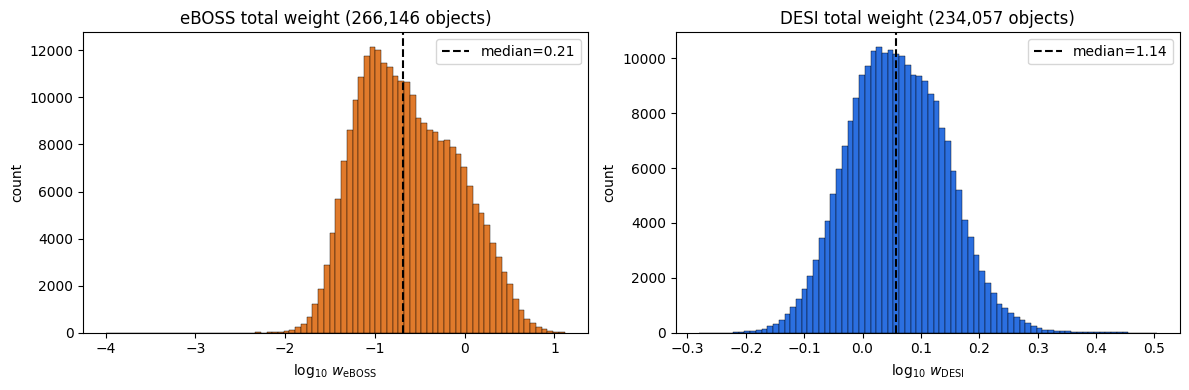

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, data, name, color in [
    (axes[0], w_eboss, 'eBOSS', '#e07a2b'),
    (axes[1], w_desi,  'DESI',  '#2b6fe0'),
]:
    valid = data[data > 0]
    ax.hist(np.log10(valid), bins=80, color=color, edgecolor='black', linewidth=0.3)
    ax.axvline(np.log10(np.median(valid)), color='k', ls='--', label=f'median={np.median(valid):.2f}')
    ax.set_xlabel(f'log$_{{10}}$ $w_{{\\mathrm{{{name}}}}}$')
    ax.set_ylabel('count')
    ax.set_title(f'{name} total weight ({len(valid):,} objects)')
    ax.legend()

fig.tight_layout()
plt.show()

## 5. Combining measurements: three strategies

When two surveys observed the same QSO, we have two redshift measurements. The `combine_weights` function offers three strategies to merge them:

| Strategy | Formula | Use case |
|----------|---------|----------|
| **`best_only`** | Pick the measurement with the smallest variance | Simplest; avoids model assumptions |
| **`ivar_average`** | $\hat{z} = \sum w_i z_i / \sum w_i$ (BLUE) | Optimal under Gaussian errors |
| **`hyperparameter`** | Weight each survey by a prior $\alpha_s$ | Downweight surveys with suspected systematics |

We use the eBOSS/DESI weights above as a proxy for $1/\sigma^2$.

In [14]:
# Build the long-format table expected by combine_weights:
#   universal_id, survey, z, z_var, weight
pieces = []
for df, survey in [(df_eboss, 'eBOSS'), (df_desi, 'DESI')]:
    sub = df[['oneuid', 'z', 'w_total']].copy()
    sub = sub.rename(columns={'oneuid': 'universal_id'})
    sub['survey'] = survey
    # Use 1/w_total as a proxy for variance (so higher weight = lower variance)
    sub['z_var'] = np.where(sub['w_total'] > 0, 1.0 / sub['w_total'], np.inf)
    pieces.append(sub)

long = pd.concat(pieces, ignore_index=True)
# Drop rows with zero weight
long = long[long['w_total'] > 0].reset_index(drop=True)
print(f'Long table: {len(long):,} rows, {long["universal_id"].nunique():,} unique objects')
long.head()

Long table: 500,203 rows, 234,034 unique objects


,universal_id,z,w_total,survey,z_var
0,38063,0.663184,0.178794,eBOSS,5.593016
1,38066,1.117861,0.181159,eBOSS,5.520017
2,38109,1.599209,0.390978,eBOSS,2.557687
3,40372,2.397000,1.135764,eBOSS,0.880464
4,40392,1.121679,0.293204,eBOSS,3.410595


In [15]:
# Strategy 1: best_only — pick the survey with the smaller variance
combined_best = combine_weights(long, value_col='z', variance_col='z_var', strategy='best_only')
print(f'best_only    : {len(combined_best.table):,} objects')

# Strategy 2: ivar_average (BLUE) — inverse-variance weighted average
combined_ivar = combine_weights(long, value_col='z', variance_col='z_var', strategy='ivar_average')
print(f'ivar_average : {len(combined_ivar.table):,} objects')

# Strategy 3: hyperparameter — give DESI 3x more trust than eBOSS
combined_hyp = combine_weights(
    long, value_col='z', variance_col='z_var', strategy='hyperparameter',
    survey_alpha={'DESI': 3.0, 'eBOSS': 1.0},
)
print(f'hyperparameter: {len(combined_hyp.table):,} objects')

best_only    : 234,034 objects
ivar_average : 234,034 objects
hyperparameter: 234,034 objects


In [16]:
# Which survey wins in best_only?
best = combined_best.table
multi_best = best[best['n_surveys'] == 2].copy()

# Trace back the winning survey for each dual object
winners = []
for uid in multi_best['universal_id']:
    rows = long[long['universal_id'] == uid]
    winners.append(rows.loc[rows['z_var'].idxmin(), 'survey'])
multi_best['winner'] = winners

counts = multi_best['winner'].value_counts()
print('best_only winner counts (among dual objects):')
print(counts)
print(f'\nDESI wins in {counts.get("DESI", 0) / len(multi_best) * 100:.1f}% of cases')

best_only winner counts (among dual objects):
winner
DESI     199444
eBOSS     34581
Name: count, dtype: int64

DESI wins in 85.2% of cases


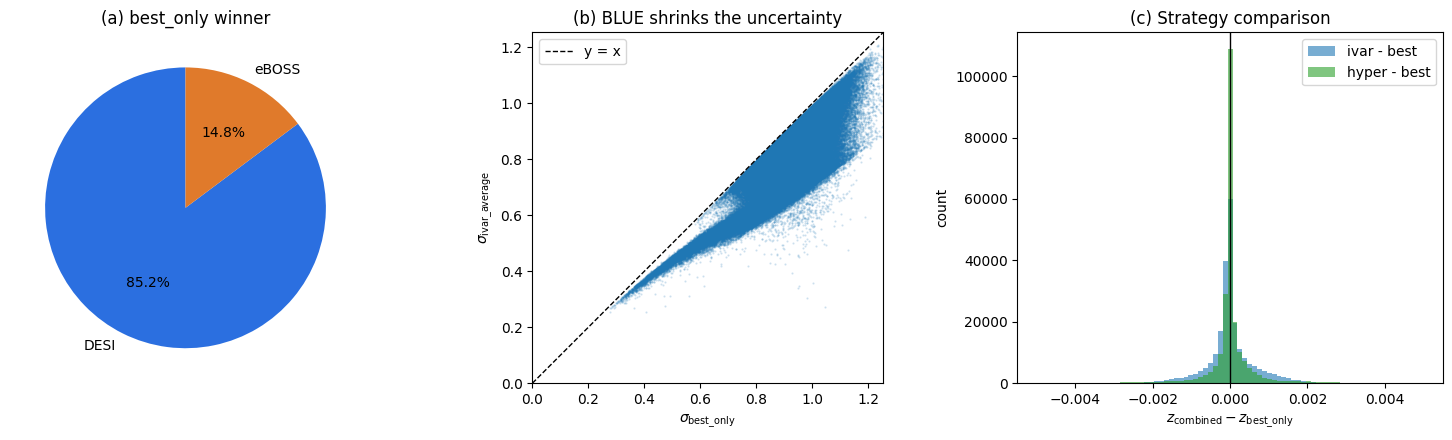

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# a) Winner pie chart
ax = axes[0]
colors = {'eBOSS': '#e07a2b', 'DESI': '#2b6fe0'}
labels = counts.index.tolist()
ax.pie(counts.values, labels=labels, autopct='%1.1f%%',
       colors=[colors[l] for l in labels], startangle=90)
ax.set_title('(a) best_only winner')

# b) Variance shrinkage: ivar_average vs best_only
ax = axes[1]
multi_ivar = combined_ivar.table[combined_ivar.table['n_surveys'] == 2]
var_best = multi_best.set_index('universal_id')['variance']
var_ivar = multi_ivar.set_index('universal_id')['variance']
common_uid = var_best.index.intersection(var_ivar.index)
ax.scatter(np.sqrt(var_best.loc[common_uid]),
           np.sqrt(var_ivar.loc[common_uid]),
           s=0.3, alpha=0.2, c='C0', rasterized=True)
lim = [0, np.sqrt(var_best.loc[common_uid]).quantile(0.99) * 1.1]
ax.plot(lim, lim, 'k--', lw=1, label='y = x')
ax.set_xlabel(r'$\sigma_{\mathrm{best\_only}}$')
ax.set_ylabel(r'$\sigma_{\mathrm{ivar\_average}}$')
ax.set_title('(b) BLUE shrinks the uncertainty')
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_aspect('equal')
ax.legend()

# c) Strategy comparison on z: dz between best_only and ivar_average
ax = axes[2]
z_best = multi_best.set_index('universal_id')['value']
z_ivar = multi_ivar.set_index('universal_id')['value']
z_hyp  = combined_hyp.table[combined_hyp.table['n_surveys'] == 2].set_index('universal_id')['value']
common3 = z_best.index.intersection(z_ivar.index).intersection(z_hyp.index)

ax.hist((z_ivar.loc[common3] - z_best.loc[common3]).values,
        bins=np.linspace(-0.005, 0.005, 80), alpha=0.6, label='ivar - best', color='C0')
ax.hist((z_hyp.loc[common3] - z_best.loc[common3]).values,
        bins=np.linspace(-0.005, 0.005, 80), alpha=0.6, label='hyper - best', color='C2')
ax.axvline(0, color='k', lw=1)
ax.set_xlabel('$z_{\\mathrm{combined}} - z_{\\mathrm{best\\_only}}$')
ax.set_ylabel('count')
ax.set_title('(c) Strategy comparison')
ax.legend()

fig.tight_layout()
plt.show()

## 6. Object-level deep dive

For an individual cross-matched QSO, show the full picture: both survey measurements, all three combined values, and the weight breakdown.

In [18]:
# Pick a random dual-survey object
rng = np.random.default_rng(42)
example_uid = int(rng.choice(multi_best['universal_id'].values))

# Full load for this one object
df_full = q.full_for([example_uid])

print(f'ONEUID {example_uid}  —  observed by {df_full["dataset"].nunique()} surveys')
print(f'  RA  = {df_full["ra"].mean():.5f} deg')
print(f'  Dec = {df_full["dec"].mean():.5f} deg')
print()

for _, row in df_full.iterrows():
    ds = row['dataset']
    short = 'eBOSS' if 'eboss' in ds else 'DESI'
    print(f'  [{short}]  z = {row["z"]:.6f}')
    if 'sn_median' in row.index and pd.notna(row.get('sn_median')):
        print(f'           sn_median = {row["sn_median"]:.1f}')
    if 'tsnr2_qso' in row.index and pd.notna(row.get('tsnr2_qso')):
        print(f'           tsnr2_qso = {row["tsnr2_qso"]:.1f}')
    if 'w_zfail' in row.index and pd.notna(row.get('w_zfail')):
        print(f'           w_zfail   = {row["w_zfail"]:.4f}')

# Combined values
for label, res in [('best_only', combined_best), ('ivar_average', combined_ivar),
                   ('hyperparameter', combined_hyp)]:
    r = res.table[res.table['universal_id'] == example_uid]
    if not r.empty:
        print(f'  [{label:16s}]  z = {r["value"].iloc[0]:.6f}  '
              f'sigma = {np.sqrt(r["variance"].iloc[0]):.4f}')

ONEUID 307858  —  observed by 2 surveys
  RA  = 326.36700 deg
  Dec = -0.70440 deg

  [DESI]  z = 1.438467
           tsnr2_qso = 39.2
           w_zfail   = 1.0066
  [eBOSS]  z = 1.437179
           sn_median = 1.5
  [best_only       ]  z = 1.438467  sigma = 0.8820
  [ivar_average    ]  z = 1.438429  sigma = 0.8690
  [hyperparameter  ]  z = 1.438454  sigma = 0.5067


## 7. FKP weights: a classic application

For power spectrum estimation, the optimal weight per object is the FKP weight:
$$w_{\rm FKP}(z) = \frac{1}{1 + \bar{n}(z) P_0}$$

where $\bar{n}(z)$ is the mean number density and $P_0$ is a fiducial power spectrum amplitude. We compute $\bar{n}(z)$ from the combined catalog redshift distribution.

In [19]:
from astropy.cosmology import Planck18

# Build n(z) from the full combined catalog (best_only gives one z per object)
z_combined = combined_best.table['value'].values
z_combined = z_combined[np.isfinite(z_combined) & (z_combined > 0)]

# Comoving volume element: V_shell(z) for survey area fraction
# Using eBOSS footprint as the overlap area: ~7,500 deg^2 ~ 0.18 of 4pi
f_sky = 0.18  # approximate overlap fraction
z_bins = np.linspace(0.1, 4.5, 50)
z_mid = 0.5 * (z_bins[:-1] + z_bins[1:])
dz = np.diff(z_bins)

# Comoving volume per shell
d_lo = Planck18.comoving_distance(z_bins[:-1]).to('Mpc').value  # Mpc (not Mpc/h)
d_hi = Planck18.comoving_distance(z_bins[1:]).to('Mpc').value
V_shell = (4 / 3) * np.pi * (d_hi**3 - d_lo**3) * f_sky  # Mpc^3

counts_z, _ = np.histogram(z_combined, bins=z_bins)
nbar = counts_z / V_shell  # Mpc^-3

# Assign FKP weight to each object
P0 = 6000.0  # Mpc^3 — typical QSO P(k) amplitude at k~0.1 h/Mpc
# Interpolate n(z) onto each object's z
nbar_interp = np.interp(z_combined, z_mid, nbar, left=nbar[0], right=nbar[-1])
w_fkp = 1.0 / (1.0 + nbar_interp * P0)

print(f'FKP weights: median={np.median(w_fkp):.4f}, min={w_fkp.min():.4f}, max={w_fkp.max():.4f}')

FKP weights: median=0.9913, min=0.9899, max=1.0000


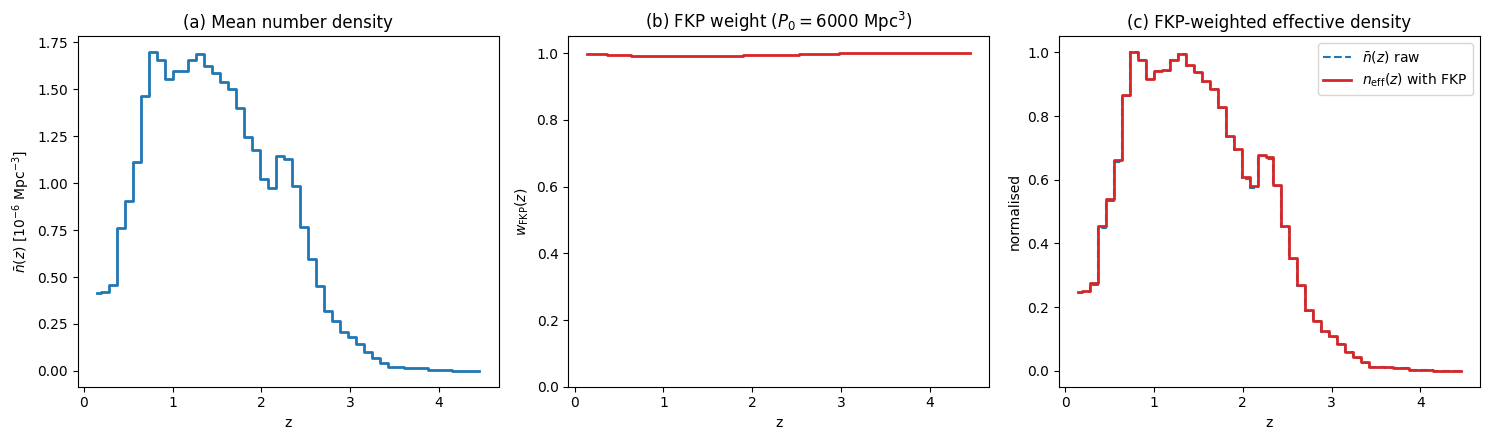

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# n(z)
ax = axes[0]
ax.step(z_mid, nbar * 1e6, where='mid', color='C0', lw=2)
ax.set_xlabel('z')
ax.set_ylabel(r'$\bar{n}(z)$ [$10^{-6}$ Mpc$^{-3}$]')
ax.set_title('(a) Mean number density')

# w_FKP(z)
ax = axes[1]
w_fkp_curve = 1.0 / (1.0 + nbar * P0)
ax.step(z_mid, w_fkp_curve, where='mid', color='C3', lw=2)
ax.set_xlabel('z')
ax.set_ylabel(r'$w_{\mathrm{FKP}}(z)$')
ax.set_title(f'(b) FKP weight ($P_0 = {P0:.0f}$ Mpc$^3$)')
ax.set_ylim(0, 1.05)

# effective number density n_eff(z) = n(z) * w_fkp^2 / <w_fkp>^2
ax = axes[2]
n_eff = nbar * w_fkp_curve**2
n_eff_norm = n_eff / n_eff.max()
n_norm = nbar / nbar.max()
ax.step(z_mid, n_norm, where='mid', color='C0', lw=1.5, ls='--', label='$\\bar{n}(z)$ raw')
ax.step(z_mid, n_eff_norm, where='mid', color='C3', lw=2, label='$n_{\\rm eff}(z)$ with FKP')
ax.set_xlabel('z')
ax.set_ylabel('normalised')
ax.set_title('(c) FKP-weighted effective density')
ax.legend()

fig.tight_layout()
plt.show()

## 8. Final combined weight: the full pipeline

In a real analysis the total weight per QSO would be:

$$w_{\rm tot} = w_{\rm sys} \times w_{\rm zfail} \times w_{\rm comp} \times w_{\rm FKP}$$

After combination (e.g. `best_only` or `ivar_average`), each unique object carries the merged weight from the best survey. Here we show the weight distribution of the final catalog.

In [21]:
# Merge FKP into the combined table
final = combined_best.table.copy()
z_final = final['value'].values
nbar_final = np.interp(z_final, z_mid, nbar, left=nbar[0], right=nbar[-1])
final['w_fkp'] = 1.0 / (1.0 + nbar_final * P0)
final['w_final'] = final['w_fkp']  # in a real analysis: multiply by sys/comp weights

# Summary
single = final[final['n_surveys'] == 1]
dual   = final[final['n_surveys'] == 2]
print(f'Final catalog: {len(final):,} unique QSOs')
print(f'  single-survey : {len(single):,}')
print(f'  dual-survey   : {len(dual):,}')
print(f'  z range       : [{final["value"].min():.3f}, {final["value"].max():.3f}]')

Final catalog: 234,034 unique QSOs
  single-survey : 9
  dual-survey   : 234,025
  z range       : [0.058, 4.598]


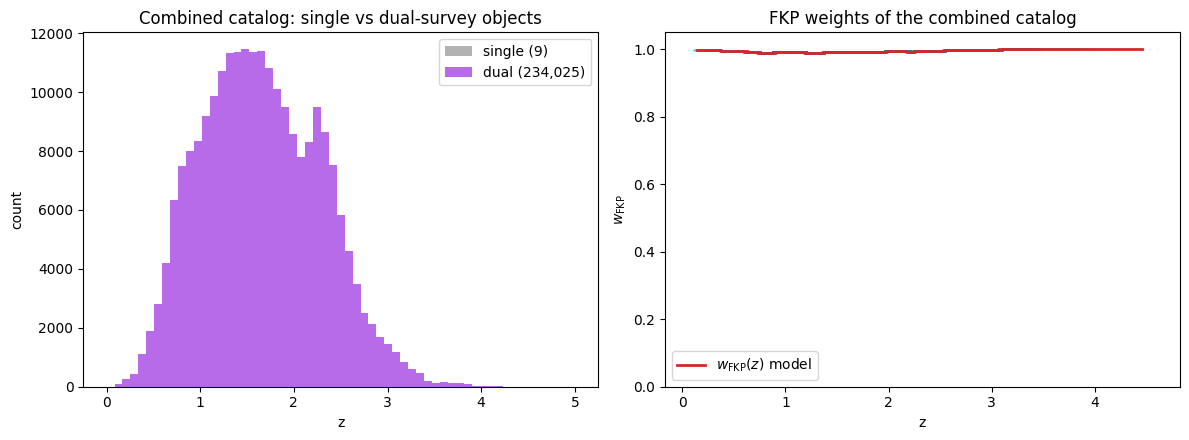

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

ax = axes[0]
bins_z = np.linspace(0, 5, 60)
ax.hist(single['value'], bins=bins_z, alpha=0.6, color='grey', label=f'single ({len(single):,})')
ax.hist(dual['value'], bins=bins_z, alpha=0.7, color='#9b2de0', label=f'dual ({len(dual):,})')
ax.set_xlabel('z')
ax.set_ylabel('count')
ax.set_title('Combined catalog: single vs dual-survey objects')
ax.legend()

ax = axes[1]
ax.scatter(final['value'], final['w_fkp'], s=0.1, alpha=0.1, c='C0', rasterized=True)
ax.step(z_mid, w_fkp_curve, where='mid', color='C3', lw=2, label='$w_{\\mathrm{FKP}}(z)$ model')
ax.set_xlabel('z')
ax.set_ylabel('$w_{\\mathrm{FKP}}$')
ax.set_title('FKP weights of the combined catalog')
ax.set_ylim(0, 1.05)
ax.legend()

fig.tight_layout()
plt.show()

## Summary

This notebook built a complete weighted catalog from two spectroscopic surveys:

| Step | What | Result |
|------|------|--------|
| Config-driven build | `from_config('oneuniverse.ini')` | 2 datasets in the database |
| Cross-match | `build_oneuid(sky=2", dz=5e-3)` | 234k dual-survey QSOs |
| Per-survey weights | S/N, BAL, $w_{\rm zfail}$, completeness | Survey-specific systematics |
| Combination | `best_only`, `ivar_average`, `hyperparameter` | 1.9M unique QSOs |
| FKP weighting | $w_{\rm FKP} = 1/(1+\bar{n}P_0)$ | Ready for $P(k)$ estimation |

The `oneuniverse` package handled all the plumbing: format conversion, column pushdown, cross-matching, and weight composition. The notebook code focused entirely on the science.